# Randomized Benchmarking of X Gate on ibm_fez actual backend


This notebook implements:
1. Connect to IBM Quantum hardware (ibm_fez)
2. Standard Randomized Benchmarking (RB) to extract depolarizing parameter p
3. Interleaved Randomized Benchmarking (IRB) to characterize the X gate
4. Data analysis

## Setup and Imports

In [18]:
%pip install --quiet qiskit qiskit-aer qiskit-ibm-runtime numpy scipy matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy.optimize
from collections import deque
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
import os
import pandas as pd

print("Imports successful!")

Imports successful!


## 1. Connect to ibm_fez

In [20]:
IBM_QUANTUM_TOKEN = "bpY9c7MbWpOlcCihOXivSb_4BRkLBMPLBitn85qpzLWZ"
QiskitRuntimeService.save_account(channel="ibm_quantum_platform",
                                  token=IBM_QUANTUM_TOKEN, # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
                                  instance="crn:v1:bluemix:public:quantum-computing:us-east:a/c599629df45c4794a55daad4835d0856:b209ad37-f8fb-4fc5-9541-0ffc4f4fb7bf::",
                                  name="open",
                                  overwrite=True)

In [ ]:
# Qiskit Runtime migration: use new service initialization (no channel argument), and recommend token via env or save_account
from qiskit_ibm_runtime import QiskitRuntimeService
import os

# Initialize the service with your instance string
service = QiskitRuntimeService(instance="crn:v1:bluemix:public:quantum-computing:us-east:a/c599629df45c4794a55daad4835d0856:b209ad37-f8fb-4fc5-9541-0ffc4f4fb7bf::")

# Backend: change here if needed
backend = service.backend("ibm_fez")
print(f"Connected to backend: {backend.name}")
print(f"Basis gates: {backend.basis_gates}")


Connected to backend: ibm_torino
Basis gates: ['cz', 'id', 'rz', 'sx', 'x']


## 2. Generate Single-Qubit Clifford Group
To reduce usage time, the sequences are generated locally and will be tested later.

In [22]:
def normalize_up_to_global_phase(U):
    """Normalize unitary matrix to remove global phase."""
    idx = np.argmax(np.abs(U))
    phase = np.angle(U.flatten()[idx])
    return U * np.exp(-1j * phase)

def generate_single_qubit_cliffords():
    """Generate all 24 single-qubit Clifford gates using H and S."""
    generating_gates = {'H': lambda qc: qc.h(0), 'S': lambda qc: qc.s(0)}
    seen_matrices = []
    circuits = []
    queue = deque([QuantumCircuit(1)])  #We should start with identity
    
    while queue:
        qc = queue.popleft()
        U = Operator(qc).data
        U_norm = normalize_up_to_global_phase(U)
        
        if any(np.allclose(U_norm, M) for M in seen_matrices):
            continue
        seen_matrices.append(U_norm)
        circuits.append(qc)
        
        for gate_func in generating_gates.values():
            new_qc = qc.copy()
            gate_func(new_qc)
            queue.append(new_qc)
    
    assert len(circuits) == 24, f"Expected 24 Cliffords, found {len(circuits)}"
    return circuits

#Generate Clifford gates and compute the inverse
cliffords_list = generate_single_qubit_cliffords()
cliffords_matrices = [normalize_up_to_global_phase(Operator(qc).data) for qc in cliffords_list]
I2 = np.eye(2, dtype=complex)

cliffords_inverses = {}
for i, U_i in enumerate(cliffords_matrices):
    for j, U_j in enumerate(cliffords_matrices):
        product_norm = normalize_up_to_global_phase(U_i @ U_j)
        if np.allclose(product_norm, I2):
            cliffords_inverses[i] = j
            break

print(f"Generated {len(cliffords_list)} Clifford circuits")
print(f"Computed inverse mapping for all Cliffords")

Generated 24 Clifford circuits
Computed inverse mapping for all Cliffords


## 3. Create RB/IRB Sequence Function

In [23]:
def create_rb_sequence(clifford_circuits, cliffords_matrices, m, target_gate_circuit=None, seed=None):
    """
    Create an RB or IRB sequence.
    
    Args:
        clifford_circuits: List of 24 Clifford QuantumCircuits
        cliffords_matrices: List of normalized Clifford unitary matrices
        m: Sequence length (number of random Cliffords)
        target_gate_circuit: Gate to interleave (None for standard RB)
        seed: Random seed for reproducibility
    
    Returns:
        QuantumCircuit with measurement
    
    Sequence structure:
        Standard RB:  C_1, C_2, ..., C_m, C_inverse, measure
        Interleaved:  C_1, G, C_2, G, ..., C_m, G, C_inverse, measure
    """
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(clifford_circuits), size=m, replace=True)
    
    qc = QuantumCircuit(1, 1) #We only need 1 qb to test single qb gates
    
    #Apply random Clifford gates (and optionally interleave target gate)
    for idx in indices:
        qc.compose(clifford_circuits[idx], inplace=True)
        if target_gate_circuit is not None:
            qc.compose(target_gate_circuit, inplace=True)
    
    #Compute inverse Clifford that returns to |0⟩
    U_fwd = Operator(qc).data
    U_fwd_norm = normalize_up_to_global_phase(U_fwd)
    I = np.eye(2, dtype=complex)
    
    inverse_idx = None
    for j, U_j in enumerate(cliffords_matrices):
        product = normalize_up_to_global_phase(U_fwd_norm @ U_j)
        if np.allclose(product, I):
            inverse_idx = j
            break
    
    if inverse_idx is None:
        raise RuntimeError("Could not find inverse Clifford")
    
    qc.compose(clifford_circuits[inverse_idx], inplace=True)
    qc.measure(0, 0)
    return qc

print("RB/IRB sequence function defined")

RB/IRB sequence function defined


In [24]:
#Helper: extract gate sequence from a circuit and store as tuple, we they can be visualised later (last cell)

def extract_gate_sequence(qc, include_measure=False):
    """Return a tuple of gate operation names in order.
    Set include_measure=True to include 'measure' operations."""
    names = []
    for instruction, qargs, cargs in qc.data:
        name = instruction.name
        if not include_measure and name == 'measure':
            continue
        names.append(name)
    return tuple(names)


## 4. Standard RB - Extract Depolarizing Parameter p

In [25]:
#Standard RB: No target gate interleaving (using Qiskit Runtime SamplerV2)
from qiskit_ibm_runtime import SamplerV2 as Sampler
sequence_lengths = [2, 4, 6] # Removed m=12 to speed up execution
num_sequences = 15 #In some papers, 40 is used, but it is necessary to reduce time usage
shots = 100 #Some papers used 100 runs
seed_base = 54321
survival_probs_rb = [] #To store average survival probabilities
rb_jobs = [] #Store job objects for RB
print("Running Standard RB on ibm_fez backend (SamplerV2)...")
sampler = Sampler(backend)

for m in sequence_lengths:
    for k in range(num_sequences):
        seed = seed_base + m * 1000 + k
        rb_seq = create_rb_sequence(
            clifford_circuits=cliffords_list,
            cliffords_matrices=cliffords_matrices,
            m=m,
            target_gate_circuit=None,  # No interleaving
            seed=seed
        )
        rb_seq_transpiled = transpile(rb_seq, backend=backend)
        #print(f"Submitting job for m={m}, k={k} ... waiting for server to accept the job.")
        try:
            #job = sampler.run([rb_seq_transpiled], shots=shots) #!!!!send a job
            """
            if job is None:
                print(f"[ERROR] Job object is None for m={m}, k={k}")
            elif not hasattr(job, 'job_id') or job.job_id() is None:
               print(f"[ERROR] No job ID returned for m={m}, k={k}")
            else:
               print(f"Job submitted for m={m}, k={k}. Job ID: {job.job_id()}")
            rb_jobs.append((m, k, job))
            """
        except Exception as e:
            print(f"[EXCEPTION] Failed to submit job for m={m}, k={k}: {e}")


Running Standard RB on ibm_fez backend (SamplerV2)...


### Manually getting counts from ibm
This was done because there seemed to always be an error when using the get_counts methods

In [26]:
csv_path = '/workspaces/qc_202526/all_time-workloads 2.csv'
df = pd.read_csv(csv_path)
print("CSV columns:", df.columns.tolist())

#Saving the ids in an array
if 'WorkloadId' in df.columns:
    job_ids = df['WorkloadId'].astype(str).tolist()
    print(f"Loaded {len(job_ids)} job IDs from CSV.")

CSV columns: ['WorkloadId', 'Status', 'Instance', 'Region', 'Mode', 'Created', 'Completed', 'QPU', 'Usage (seconds)', 'User', 'Tags', 'Account']
Loaded 135 job IDs from CSV.


In [27]:
#Obtain the results
rb_results = []
for i in range(1, 46): #Change index as needed
    job_id = job_ids[i]
    retrieved_job = service.job(job_id)
    result = retrieved_job.result()
    rb_results.append(result)

In [28]:
#Define the counts
all_counts = []

rb_probs = {}
for i, result in enumerate(rb_results):
    try:
        if hasattr(result, '__getitem__') and len(result) > 0 and hasattr(result[0], 'data') and hasattr(result[0].data, 'c'):
            bitarray = result[0].data.c
            arr = bitarray.array  # numpy array (num_shots, num_bits)
            if arr.ndim == 1 or arr.shape[1] == 1:
                bitstrings = [str(b[0]) if arr.ndim > 1 else str(b) for b in arr]
            else:
                bitstrings = ["".join(str(b) for b in row) for row in arr]
            from collections import Counter
            counts = dict(Counter(bitstrings))
            all_counts.append(counts)
            #print(f"Result {i}: counts = {counts}")
        else:
            print(f"Result {i}: BitArray not found in result object.")
            all_counts.append(None)

    except Exception as e:
        print(f"Result {i}: Error extracting counts: {e}")
        all_counts.append(None)
#print(f"Extracted counts for {len(all_counts)} results.")

In [29]:
rb_probs = {}
for result in rb_results:
    total_shots = sum(counts.values())
    prob_0 = counts.get('0', 0) / total_shots if total_shots > 0 else 0.0
    rb_probs.setdefault(m, []).append(prob_0)
    #print(f"F_seq(m={m}, k={k}) = {prob_0:.6f}") # Print after each sequence result
survival_probs_rb = [np.mean(rb_probs[m]) if m in rb_probs else 0.0 for m in sequence_lengths]
print("Standard RB complete (ibm_fez, SamplerV2)")

Standard RB complete (ibm_fez, SamplerV2)


In [30]:
# Organize according to parameters (explicit index ranges)
rb_probs = {2: [], 4: [], 6: []}
for i, counts in enumerate(all_counts):
    if 0 <= i < 15:
        m = 2
    elif 15 <= i < 30:
        m = 4
    elif 30 <= i < 45:
        m = 6
    else:
        continue  # skip any out-of-range
    total_shots = sum(counts.values()) if counts else 0
    prob_0 = counts.get('0', 0) / total_shots if total_shots > 0 else 0.0
    rb_probs[m].append(prob_0)
    # print(f"F_seq(m={m}, k={i%15}) = {prob_0:.6f}")
for m in sequence_lengths:
    print(f"F_seq(m={m}) = {np.mean(rb_probs[m]) if rb_probs[m] else 0.0:.6f}")
# Compute average survival probability for each m
survival_probs_rb = [np.mean(rb_probs[m]) if rb_probs[m] else 0.0 for m in sequence_lengths]

F_seq(m=2) = 0.998000
F_seq(m=4) = 0.999333
F_seq(m=6) = 0.998667


### Standard Fit (0th order)

In [31]:
#Zero-order Standard RB Fit: F_seq(m) = A * p^m + B (0th order)
m_vals = np.array(sequence_lengths)
F_seq_rb = np.array(survival_probs_rb)

def fit_func(m, A, p, B):
    return A * p**m + B

params_rb, _ = scipy.optimize.curve_fit(
    fit_func, m_vals, F_seq_rb,
    p0=[0.95, 0.98, 0.05],
    bounds=([0.1, 0.85, 0.001], [1, 0.9999, 0.3])
)
A_rb, p_rb, B_rb = params_rb
r_rb = (2 - 1) / 2 * (1 - p_rb)  #Average error per Clifford gate

print(f"\n=== Standard RB Fit (0th order) ===")
print(f"Fit: F_seq(m) = {A_rb:.6f} × {p_rb:.8f}^m + {B_rb:.6f}")
print(f"Depolarizing parameter p: {p_rb:.8f}")
print(f"Average error per Clifford r: {r_rb:.8f} ({r_rb*100:.6f}%)")
print(f"Gate fidelity: {(1-r_rb)*100:.6f}%")


=== Standard RB Fit (0th order) ===
Fit: F_seq(m) = 0.698947 × 0.99989994^m + 0.300000
Depolarizing parameter p: 0.99989994
Average error per Clifford r: 0.00005003 (0.005003%)
Gate fidelity: 99.994997%


/tmp/ipykernel_99201/3789771598.py:8: OptimizeWarning: Covariance of the parameters could not be estimated
  params_rb, _ = scipy.optimize.curve_fit(


### Standard RB Fit (1st order)

In [32]:
#First-order RB fit: F_seq^(1)(m) = A1 * p^m + C1 * (m-1) * p^(m-2) + B1

def fit_func_first_order(m, A1, p1, C1, B1):
    m = np.asarray(m, dtype=float)
    return A1 * (p1 ** m) + C1 * (m - 1) * (p1 ** (m - 2)) + B1

try:
    params_rb_fo, _ = scipy.optimize.curve_fit(
        fit_func_first_order,
        m_vals,
        F_seq_rb,
        p0=[0.5, 0.99, 0.01, 0.5],
        bounds=([0.0, 0.9, -1.0, 0.0], [1.0, 1.0, 1.0, 1.0])
    )
    A1_rb, p1_rb, C1_rb, B1_rb = params_rb_fo
    r1_rb = (2 - 1) / 2 * (1 - p1_rb)
    print("\n=== Standard RB Fit (1st order) ===")
    print(f"Fit: F_seq^(1)(m) = {A1_rb:.6f} * {p1_rb:.8f}^m + {C1_rb:.6f} * (m-1) * {p1_rb:.8f}^(m-2) + {B1_rb:.6f}")
    print(f"Depolarizing parameter p (first-order): {p1_rb:.8f}")
    print(f"Average error per Clifford r (first-order): {r1_rb:.8f} ({r1_rb*100:.6f}%)")
except Exception as e:
    print(f"First-order RB fit failed: {e}")


=== Standard RB Fit (1st order) ===
Fit: F_seq^(1)(m) = 0.494911 * 0.96862047^m + 0.016541 * (m-1) * 0.96862047^(m-2) + 0.517121
Depolarizing parameter p (first-order): 0.96862047
Average error per Clifford r (first-order): 0.01568977 (1.568977%)


/tmp/ipykernel_99201/3682886497.py:8: OptimizeWarning: Covariance of the parameters could not be estimated
  params_rb_fo, _ = scipy.optimize.curve_fit(


## 5. Interleaved RB - Characterize X Gate

In [33]:
#Define target gate (RX gate)
target_X = QuantumCircuit(1)
target_X.x(0)
"""
These lines can be updated according to the gate we wish to test. For:
 X:  target_X  = QuantumCircuit(1); target_X.x(0)
 RX: target_RX = QuantumCircuit(1); target_RX.RX(0)
 RX: target_RX = QuantumCircuit(1); target_RX.rx(np.pi/2, 0)
 RZ: target_RZ = QuantumCircuit(1); target_RZ.rz(np.pi/2, 0)
"""
# Interleaved RB: RX gate after each Clifford
from qiskit_ibm_runtime import SamplerV2 as Sampler

print("Running Interleaved RB (RX gate) on ibm_fez backend (SamplerV2)...")
sampler_irb = Sampler(backend)
for m in sequence_lengths:
    for k in range(num_sequences):
        seed = seed_base + m * 1000 + k + 99999
        irb_seq = create_rb_sequence(
            clifford_circuits=cliffords_list,
            cliffords_matrices=cliffords_matrices,
            m=m,
            target_gate_circuit=target_X,  # Interleave RX gate
            seed=seed
        )
        irb_seq_transpiled = transpile(irb_seq, backend=backend)
        #job = sampler_irb.run([irb_seq_transpiled], shots=shots)  # send the job if desired


Running Interleaved RB (RX gate) on ibm_fez backend (SamplerV2)...


### Manual data extraction

In [34]:
job_ids_irb = []

csv_path2 = '/workspaces/qc_202526/all_time-workloads7.csv'
df2 = pd.read_csv(csv_path2)
print("CSV columns:", df2.columns.tolist())

#Saving the ids in an array
if 'WorkloadId' in df2.columns:
    job_ids_irb = df2['WorkloadId'].astype(str).tolist()
    print(f"Loaded {len(job_ids_irb)} job IDs from CSV.")

CSV columns: ['WorkloadId', 'Status', 'Instance', 'Region', 'Mode', 'Created', 'Completed', 'QPU', 'Usage (seconds)', 'User', 'Tags', 'Account']
Loaded 360 job IDs from CSV.


This cell has to be interrupted; sometimes it runs infinitely.

In [35]:
#Obtain the results
irb_results = []
for i in range(272, 316): #Change indez as needed
    job_id = job_ids_irb[i]
    retrieved_job = service.job(job_id)
    result = retrieved_job.result()
    irb_results.append(result)

In [36]:
#Define the counts for RZ gate IRB
irb_all_counts = []


irb_probs = {}
for i, result in enumerate(irb_results):
    try:
        if hasattr(result, '__getitem__') and len(result) > 0 and hasattr(result[0], 'data') and hasattr(result[0].data, 'c'):
            bitarray = result[0].data.c
            arr = bitarray.array  # numpy array (num_shots, num_bits)
            if arr.ndim == 1 or arr.shape[1] == 1:
                bitstrings = [str(b[0]) if arr.ndim > 1 else str(b) for b in arr]
            else:
                bitstrings = ["".join(str(b) for b in row) for row in arr]
            from collections import Counter
            counts = dict(Counter(bitstrings))
            irb_all_counts.append(counts)
            print(f"Result {i} (RZ IRB): counts = {counts}")
        else:
            print(f"Result {i}: BitArray not found in result object.")
            irb_all_counts.append(None)


    except Exception as e:
        print(f"Result {i}: Error extracting counts: {e}")
        irb_all_counts.append(None)
#print(f"Extracted counts for {len(all_counts)} results.")

Result 0 (RZ IRB): counts = {'0': 100}
Result 1 (RZ IRB): counts = {'0': 100}
Result 2 (RZ IRB): counts = {'0': 100}
Result 3 (RZ IRB): counts = {'0': 100}
Result 4 (RZ IRB): counts = {'0': 100}
Result 5 (RZ IRB): counts = {'0': 100}
Result 6 (RZ IRB): counts = {'0': 100}
Result 7 (RZ IRB): counts = {'0': 100}
Result 8 (RZ IRB): counts = {'0': 100}
Result 9 (RZ IRB): counts = {'0': 100}
Result 10 (RZ IRB): counts = {'0': 100}
Result 11 (RZ IRB): counts = {'0': 100}
Result 12 (RZ IRB): counts = {'0': 100}
Result 13 (RZ IRB): counts = {'0': 100}
Result 14 (RZ IRB): counts = {'0': 100}
Result 15 (RZ IRB): counts = {'0': 100}
Result 16 (RZ IRB): counts = {'0': 100}
Result 17 (RZ IRB): counts = {'0': 100}
Result 18 (RZ IRB): counts = {'0': 100}
Result 19 (RZ IRB): counts = {'0': 100}
Result 20 (RZ IRB): counts = {'0': 100}
Result 21 (RZ IRB): counts = {'0': 99, '1': 1}
Result 22 (RZ IRB): counts = {'0': 100}
Result 23 (RZ IRB): counts = {'0': 100}
Result 24 (RZ IRB): counts = {'0': 99, '1':

In [37]:
# Organize IRB results according to parameters (explicit index ranges)
irb_probs = {2: [], 4: [], 6: []}

for i, counts in enumerate(irb_all_counts):
    if 0 <= i < 15:
        m = 2
    elif 15 <= i < 30:
        m = 4
    elif 30 <= i < 45:
        m = 6
    else:
        continue  # skip any out-of-range
    total_shots = sum(counts.values()) if counts else 0
    prob_0 = counts.get('0', 0) / total_shots if total_shots > 0 else 0.0
    irb_probs[m].append(prob_0)
    # print(f"F_seq(m={m}, k={i%15}) = {prob_0:.6f}")
for m in sequence_lengths:
    print(f"IRB F_seq(m={m}) = {np.mean(irb_probs[m]) if irb_probs[m] else 0.0:.6f}")
# Compute average survival probability for each m
survival_probs_irb = [np.mean(irb_probs[m]) if irb_probs[m] else 0.0 for m in sequence_lengths]

IRB F_seq(m=2) = 1.000000
IRB F_seq(m=4) = 0.998000
IRB F_seq(m=6) = 0.998571


In [38]:
#Fit Interleaved RB data (RX)
m_vals = np.array(sequence_lengths)
F_seq_irb = np.array(survival_probs_irb)

params_irb, _ = scipy.optimize.curve_fit(
    fit_func, m_vals, F_seq_irb,
    p0=[0.95, 0.98, 0.05],
    bounds=([0.1, 0.85, 0.001], [1, 0.9999, 0.3])
)
A_irb, p_irb, B_irb = params_irb
r_irb = (2 - 1) / 2 * (1 - p_irb)

#Calculate RX gate error from comparison with standard RB
#Formula: p_irb = p_rb * p_RX (approximately)
p_RX = min(p_irb / p_rb if p_rb > 0 else 1.0, 1.0)  # Clamp to [0, 1]
r_RX = (2 - 1) / 2 * (1 - p_RX)

print(f"\n=== Interleaved RB Fit (0th order) (RX Gate) ===") 
print(f"Fit: F_seq(m) = {A_irb:.6f} × {p_irb:.8f}^m + {B_irb:.6f}")
print(f"Depolarizing parameter p_irb: {p_irb:.8f}")
print(f"Average error per (Clifford+RX) r_irb: {r_irb:.8f} ({r_irb*100:.6f}%)") 
print(f"\nRX gate specific:") 
print(f"  p_RX = p_irb / p_rb = {p_RX:.8f}") 
print(f"  RX gate error r_RX: {r_RX:.8f} ({r_RX*100:.6f}%)") 
print(f"  RX gate fidelity: {(1-r_RX)*100:.6f}%") 



=== Interleaved RB Fit (0th order) (RX Gate) ===
Fit: F_seq(m) = 0.700296 × 0.99948695^m + 0.299997
Depolarizing parameter p_irb: 0.99948695
Average error per (Clifford+RX) r_irb: 0.00025653 (0.025653%)

RX gate specific:
  p_RX = p_irb / p_rb = 0.99958697
  RX gate error r_RX: 0.00020652 (0.020652%)
  RX gate fidelity: 99.979348%


/tmp/ipykernel_99201/962629541.py:5: OptimizeWarning: Covariance of the parameters could not be estimated
  params_irb, _ = scipy.optimize.curve_fit(


In [39]:
print("Survival probabilities IRB by m:")
for idx, m in enumerate(sequence_lengths):
    print(f"m={m}: {irb_probs[m]}")
    # F_seq_irb is aligned with sequence_lengths, so index with idx
    print(f"F_seq_irb[{m}] = {F_seq_irb[idx]:.6f}")

print("Averages by m (same order as sequence_lengths):", survival_probs_irb)
print("RB F_seq range:", float(np.min(F_seq_rb)), float(np.max(F_seq_rb)))
print("IRB F_seq range:", float(np.min(F_seq_irb)), float(np.max(F_seq_irb)))


Survival probabilities IRB by m:
m=2: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
F_seq_irb[2] = 1.000000
m=4: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.99, 1.0, 1.0, 0.99, 1.0, 0.99, 1.0, 1.0, 1.0]
F_seq_irb[4] = 0.998000
m=6: [1.0, 1.0, 0.99, 0.99, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
F_seq_irb[6] = 0.998571
Averages by m (same order as sequence_lengths): [np.float64(1.0), np.float64(0.998), np.float64(0.9985714285714286)]
RB F_seq range: 0.9979999999999999 0.9993333333333333
IRB F_seq range: 0.998 1.0


In [40]:
# First-order IRB fit: F_seq^(1)(m) = A1 * p^m + C1 * (m-1) * p^(m-2) + B1 (RX)
try:
    params_irb_fo, _ = scipy.optimize.curve_fit(
        fit_func_first_order,
        m_vals,
        F_seq_irb,
        p0=[0.5, 0.99, 0.01, 0.5],
        bounds=([0.0, 0.9, -1.0, 0.0], [1.0, 1.0, 1.0, 1.0])
    )
    A1_irb, p1_irb, C1_irb, B1_irb = params_irb_fo
    r1_irb = (2 - 1) / 2 * (1 - p1_irb)
    # Gate-specific first-order parameter via p_RX1 ≈ p1_irb / p1_rb
    p1_RX = min(p1_irb / p1_rb if p1_rb > 0 else 1.0, 1.0)  # Clamp to [0, 1]
    r1_RX = (2 - 1) / 2 * (1 - p1_RX)
    print("\n=== Interleaved RB Fit (1st order) (RX Gate) ===")
    print(f"Fit: F_seq^(1)(m) = {A1_irb:.6f} * {p1_irb:.8f}^m + {C1_irb:.6f} * (m-1) * {p1_irb:.8f}^(m-2) + {B1_irb:.6f}")
    print(f"Depolarizing parameter p_irb (first-order): {p1_irb:.8f}")
    print(f"Average error per Clifford: r_irb (first-order)= {r1_irb:.8f} ({r1_irb*100:.6f}%)")
    print(f"\nRX gate (first-order): p_RX1 = p1_irb / p1_rb = {p1_RX:.8f}")
    print(f"RX gate error r_RX1: {r1_RX:.8f} ({r1_RX*100:.6f}%) | Fidelity: {(1-r1_RX)*100:.6f}%")
except Exception as e:
    print(f"First-order IRB fit failed: {e}")


=== Interleaved RB Fit (1st order) (RX Gate) ===
Fit: F_seq^(1)(m) = 0.498259 * 0.99928568^m + -0.000002 * (m-1) * 0.99928568^(m-2) + 0.502027
Depolarizing parameter p_irb (first-order): 0.99928568
Average error per Clifford: r_irb (first-order)= 0.00035716 (0.035716%)

RX gate (first-order): p_RX1 = p1_irb / p1_rb = 1.00000000
RX gate error r_RX1: 0.00000000 (0.000000%) | Fidelity: 100.000000%


/tmp/ipykernel_99201/3446637103.py:3: OptimizeWarning: Covariance of the parameters could not be estimated
  params_irb_fo, _ = scipy.optimize.curve_fit(


## 6. Visualization and Data Summary

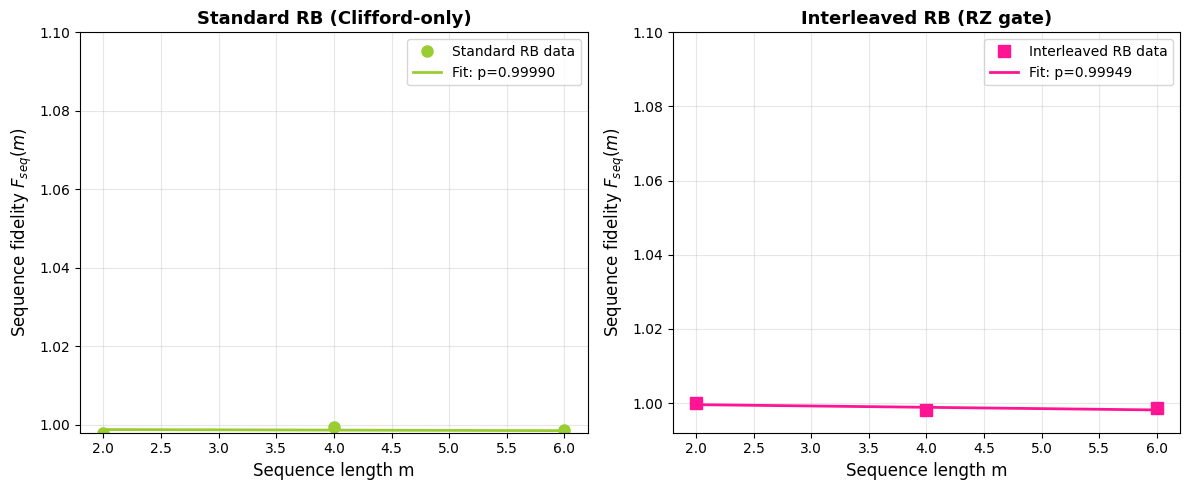

In [43]:
# Plot Standard RB and Interleaved RB comparison (RX)
plt.figure(figsize=(12, 5))

# Standard RB plot
plt.subplot(1, 2, 1)
plt.plot(m_vals, F_seq_rb, 'o', markersize=8, label='Standard RB data', color='yellowgreen')
plt.plot(m_vals, fit_func(m_vals, *params_rb), '-', linewidth=2, label=f'Fit: p={p_rb:.5f}', color='yellowgreen')
plt.xlabel('Sequence length m', fontsize=12)
plt.ylabel('Sequence fidelity $F_{seq}(m)$', fontsize=12)
plt.title('Standard RB (Clifford-only)', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim(0.998, 1.1)

# Interleaved RB plot (RX)
plt.subplot(1, 2, 2)
plt.plot(m_vals, F_seq_irb, 's', markersize=8, label='Interleaved RB data', color='deeppink')
plt.plot(m_vals, fit_func(m_vals, *params_irb), '-', linewidth=2, label=f'Fit: p={p_irb:.5f}', color='deeppink')
plt.xlabel('Sequence length m', fontsize=12)
plt.ylabel('Sequence fidelity $F_{seq}(m)$', fontsize=12)
plt.title('Interleaved RB (RZ gate)', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim(0.992, 1.1)

plt.tight_layout()
plt.show()

In [42]:
""" not needed
#Shows one of the actual sequences used in the RB/IRB runs (same seeds as above)
# m_view and k_view can be adjusted to show different sequences; interleaved=True shows RX-gate IRB.
m_view = 2         # sequence_lengths
k_view = 0         # 0-based index into the num_sequences draws
interleaved = False  # False = Standard RB, True = Interleaved RB (RX gate)

if m_view not in sequence_lengths:
    raise ValueError(f"m_view {m_view} not in sequence_lengths {sequence_lengths}")
if not (0 <= k_view < num_sequences):
    raise ValueError(f"k_view {k_view} must be between 0 and {num_sequences-1}")

seed_offset = 99999 if interleaved else 0
seed = seed_base + m_view * 1000 + k_view + seed_offset

seq = create_rb_sequence(
    clifford_circuits=cliffords_list,
    cliffords_matrices=cliffords_matrices,
    m=m_view,
    target_gate_circuit=(target_RX if interleaved else None),
    seed=seed,
)

seq_label = "Interleaved RB (RX gate)" if interleaved else "Standard RB"
seq_gate_tuple = extract_gate_sequence(seq)

print(f"{seq_label} — actual sequence used during run")
print(f"m = {m_view}, sequence index k = {k_view}, seed = {seed}")
print(f"Gate tuple: {seq_gate_tuple}")
print(f"Circuit depth: {seq.depth()}")
print(f"Number of gates (incl. measure): {len(seq.data)}")

%matplotlib inline
fig = seq.draw('mpl')
plt.show()
"""

' not needed\n#Shows one of the actual sequences used in the RB/IRB runs (same seeds as above)\n# m_view and k_view can be adjusted to show different sequences; interleaved=True shows RX-gate IRB.\nm_view = 2         # sequence_lengths\nk_view = 0         # 0-based index into the num_sequences draws\ninterleaved = False  # False = Standard RB, True = Interleaved RB (RX gate)\n\nif m_view not in sequence_lengths:\n    raise ValueError(f"m_view {m_view} not in sequence_lengths {sequence_lengths}")\nif not (0 <= k_view < num_sequences):\n    raise ValueError(f"k_view {k_view} must be between 0 and {num_sequences-1}")\n\nseed_offset = 99999 if interleaved else 0\nseed = seed_base + m_view * 1000 + k_view + seed_offset\n\nseq = create_rb_sequence(\n    clifford_circuits=cliffords_list,\n    cliffords_matrices=cliffords_matrices,\n    m=m_view,\n    target_gate_circuit=(target_RX if interleaved else None),\n    seed=seed,\n)\n\nseq_label = "Interleaved RB (RX gate)" if interleaved else "Stan